In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout


In [2]:
df = pd.read_csv("NIFTY50.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

data = df[['Close']]


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


In [4]:
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)


In [5]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [6]:
model = Sequential()

# CNN layers
model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                 input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))

# Bi-LSTM layers
model.add(Bidirectional(LSTM(50, return_sequences=True)))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(50)))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()


/Users/krish/stock_ml/venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 29, 100)        │        46,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 29, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,757 (417.02 KB)

 Trainable params: 106,757 (417.02 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0022 - val_loss: 0.0059
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011 - val_loss: 0.0041
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.6721e-04 - val_loss: 0.0029
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.5057e-04 - val_loss: 0.0022
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.7172e-04 - val_loss: 0.0018
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.8569e-04 - val_loss: 0.0017
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.0708e-04 - val_loss: 0.0015
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.9649e-04 - val_loss: 0.0012
Epoch 9/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.1017e-04 - val_loss: 0.0011
Epoch 10/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.0908e-04 - val_loss: 0.0012
Epoch 11/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.2094e-04 - val_loss: 0.0011
Epoch 12/30
75/75 ━━━━━━━━━

In [8]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [9]:
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
mae = mean_absolute_error(y_test_actual, test_predict)
r2 = r2_score(y_test_actual, test_predict)

print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

RMSE: 2.6915683562459747
MAE: 1.2714618050675224
R² Score: 0.9275488615740928


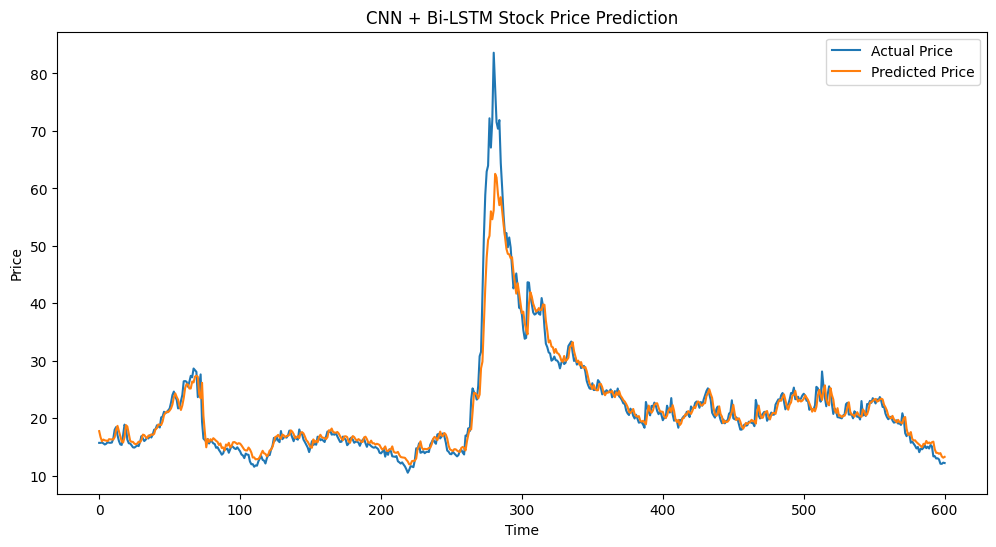

In [10]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(test_predict, label='Predicted Price')
plt.title('CNN + Bi-LSTM Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()
